# IT Support Dashboard - Supporting Notebook 2

This series of notebooks contains supporting documentation to the full report. Here, we provide quality checks for the full dataset, confirm whether the English-only sample is representitive of the full population available, and conduct text analytics.

## Representativeness check

Notebook 2 provides the representativeness check for the cleaned dataset. This was carried out because the dataset contained records with English and German responses. It was thought that the variation in language would affect the text analytics planned later. Additionally, we assumed that the primary audience of this analysis spoke English and wouldn't find the German results relevant or useful.

The following actions were taken:
- Subsetting English records
- Carried out a representativeness check to confirm if the English-only subset remained statistically representative to the full dataset, and avoided sampling bias
- Measured the following in dimensions: Type, Queue, Priority, and Version:
    - Absolute proportion shifts and visualised using horizontal bar charts
    - Chi-square test
    - Cramér’s V strength of associations test

### Importing

First, the required packages for this process were imported, the necessary folders were created using the config file, and the clean dataset was read.

In [25]:
# Importing essential packages
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Add parent directory (project root) to sys.path
project_root = Path(r"C:\Users\David\Desktop\Python_Files\IT-Support-Ticket-Analysis")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from config import Config

Config.ensure_directories()

# Reading the initial dataset as a DataFrame: df
df = pd.read_parquet(Config.CLEAN_PARQUET_PATH, engine="pyarrow")

display(df)

[Config] Verified project directory structure under C:\Users\David\Desktop\Python_Files\IT-Support-Ticket-Analysis


,Subject,Body,Answer,Type,Queue,Priority,Language,Version,Tag_1,Tag_2,Tag_3,Tag_4,Tag_5,Tag_6,Tag_7,Tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team, ich möchte einen g...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,High,DE,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team, I am writing to re...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,High,EN,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team, I hope this messag...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,Medium,EN,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team, I hope this messag...",We appreciate you reaching out with your billi...,Request,Billing and Payments,Low,EN,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team, I hope this message reaches...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,Medium,EN,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24738,Performance Problem with Data Analytics Tool,The data analytics tool experiences sluggish p...,We are addressing the performance issue with t...,Incident,Technical Support,High,EN,400,Performance,IT,Tech Support,NaN,NaN,NaN,NaN,NaN
24739,Datensperrung in der Kundschaftsbetreuung,"Es gab einen Datensperrungsunfall, bei dem ung...",Ich kann Ihnen bei dem Datensperrungsunfall he...,Incident,Product Support,High,DE,400,Security,IT,Tech Support,Bug,NaN,NaN,NaN,NaN
24740,Problem mit der Videokonferenz-Software heute,Wichtigere Sitzungen wurden unterbrochen durch...,"Sehr geehrte/r [Name], leider wurde das Proble...",Incident,Human Resources,Low,DE,400,Bug,Performance,Network,IT,Tech Support,NaN,NaN,NaN
24741,Update Request for SaaS Platform Integration F...,Requesting an update on the integration featur...,Received your request for updates on the integ...,Change,IT Support,High,EN,400,Feature,IT,Tech Support,NaN,NaN,NaN,NaN,NaN


### Subsetting English data

English resposnses accounted for 55.49% (13,729) of all records, which was a severe reduction in the usable data. Due to the significance of this reduction, it was thought to be necessary to carry out representativeness checks.

In [20]:
# Create an English-only subset
df_en = df[df["Language"] == "EN"].copy()

# Saving the English-only subset to CSV
df_en.to_csv(Config.ENGLISH_CSV_PATH, index=False, encoding="latin-1")
df_en.to_parquet(
    Config.ENGLISH_PARQUET_PATH, index=False, engine="pyarrow", compression="snappy"
)

# Calculate the percentage reduction of records from subsetting
english_percentage = len(df_en) / len(df)
german_percentage = 1 - english_percentage

print(f"\nEnglish-only rows: {len(df_en):,}, accounting for {english_percentage:.2%}")
print(
    f"\nGerman-only rows: {len(df) - len(df_en):,}, accounting for {german_percentage:.2%}"
)


English-only rows: 13,729, accounting for 55.49%

German-only rows: 11,014, accounting for 44.51%


### Absolute Proportion Shifts

First, we wanted to see if subsetting for English-only entries would bias the population. For this purpose, we employed Absolute Proportion Shifts analysis to:
- Establish if clustering insights derived from the English subset could be generalised back to the full service population with minimal distributional distortion
- Reduce the risk that high-actionability clusters (e.g. security breaches or integration failures) are artefacts of language-based reporting behaviour rather than true operational recurrence
- Provide an empirical justification for excluding non-English tickets to simplify NLP processing without materially altering business-relevant ticket composition

In [21]:
# Define a function to compare distributions of a categorical column between the full dataset and the English-only subset
def compare_distribution(col, top_n=None):
    """Produce comparison table for a categorical column."""
    full_counts = df[col].value_counts(dropna=False)
    en_counts = df_en[col].value_counts(dropna=False)

    full_total = full_counts.sum()
    en_total = en_counts.sum()

    # Align both count Series by their shared index (all categories in either dataset)
    result = (
        pd.DataFrame({"full_count": full_counts, "en_count": en_counts})
        .fillna(0)
        .astype({"full_count": int, "en_count": int})
        .sort_values("full_count", ascending=False)
    )

    if top_n is not None:
        result = result.head(top_n)

    result["full_pct"] = result["full_count"] / full_total
    result["en_pct"] = result["en_count"] / en_total
    result["abs_pct_diff"] = result["en_pct"] - result["full_pct"]
    result["rel_pct_diff"] = result["abs_pct_diff"] / result["full_pct"].replace(
        0, np.nan
    )

    return result.reset_index(names=col)


# Compute distributions and summary metrics
distributions = {}
summary = []
comparrison_cols = {"02": "Priority", "03": "Type", "04": "Queue", "05": "Version"}

# Loop through the dimensions array to produce summary tables for absolute proportional shifts
for col in comparrison_cols.values():
    # Error message for missed dimensions
    if col not in df.columns:
        print(f"WARNING: column '{col}' not in dataset — skipping.")
        continue

    print(f"\nDistributions table for {col} column:")

    dist = compare_distribution(col)
    distributions[col] = dist

    # L1 metric (sum absolute proportion diffs)
    L1 = dist["abs_pct_diff"].abs().sum()
    idx_max = dist["abs_pct_diff"].abs().idxmax()
    max_cat = dist.loc[idx_max, col]
    max_abs = dist.loc[idx_max, "abs_pct_diff"]

    summary.append(
        {
            "Dimension": col,
            "max_diff_category": max_cat,
            "L1_total_abs_pct_diff": L1,
            "max_abs_pct_diff": max_abs,
        }
    )

    dist.sort_values("abs_pct_diff", ascending=False, inplace=True)

    # show the small table
    display(
        dist.style.format(
            {
                "full_count": "{:,}",
                "en_count": "{:,}",
                "full_pct": "{:.2%}",
                "en_pct": "{:.2%}",
                "abs_pct_diff": "{:.3%}",
                "rel_pct_diff": "{:.3%}",
            }
        )
    )

    # Key of column
    position = list(comparrison_cols.keys())[list(comparrison_cols.values()).index(col)]

    dist.to_csv(
        Config.REP_SHEETS_DIR / f"{position}_Distribution_Comparison_{col}.csv",
        index=False,
        encoding="latin-1",
    )

# Create the summary of distributions dataframe
absolute_shifts_df = pd.DataFrame(summary)
absolute_shifts_df.sort_values("L1_total_abs_pct_diff", ascending=False, inplace=True)

print("\nSummary of distribution shifts:")

display(
    absolute_shifts_df.style.format(
        {"L1_total_abs_pct_diff": "{:.2%}", "max_abs_pct_diff": "{:.2%}"}
    )
)

absolute_shifts_df.to_csv(Config.ABSOLUTE_SHIFT_PATH, index=False, encoding="latin-1")


Distributions table for Priority column:


,Priority,full_count,en_count,full_pct,en_pct,abs_pct_diff,rel_pct_diff
0,Medium,"9,975","5,593",40.31%,40.74%,0.424%,1.052%
2,Low,"5,115","2,832",20.67%,20.63%,-0.045%,-0.216%
1,High,"9,653","5,304",39.01%,38.63%,-0.380%,-0.973%



Distributions table for Type column:


,Type,full_count,en_count,full_pct,en_pct,abs_pct_diff,rel_pct_diff
3,Change,"2,484","1,397",10.04%,10.18%,0.136%,1.358%
0,Incident,"9,950","5,531",40.21%,40.29%,0.074%,0.183%
1,Request,"7,079","3,929",28.61%,28.62%,0.008%,0.028%
2,Problem,"5,230","2,872",21.14%,20.92%,-0.218%,-1.032%



Distributions table for Queue column:


,Queue,full_count,en_count,full_pct,en_pct,abs_pct_diff,rel_pct_diff
1,Product Support,"4,560","2,606",18.43%,18.98%,0.552%,2.997%
8,Human Resources,473,285,1.91%,2.08%,0.164%,8.592%
6,Service Outages and Maintenance,"1,024",581,4.14%,4.23%,0.093%,2.256%
5,Returns and Exchanges,"1,226",686,4.95%,5.00%,0.042%,0.843%
4,Billing and Payments,"2,425","1,349",9.80%,9.83%,0.025%,0.257%
9,General Inquiry,337,187,1.36%,1.36%,0.000%,0.006%
7,Sales and Pre-Sales,763,410,3.08%,2.99%,-0.097%,-3.156%
3,IT Support,"2,943","1,609",11.89%,11.72%,-0.175%,-1.468%
2,Customer Service,"3,732","2,045",15.08%,14.90%,-0.188%,-1.244%
0,Technical Support,"7,260","3,971",29.34%,28.92%,-0.417%,-1.423%



Distributions table for Version column:


,Version,full_count,en_count,full_pct,en_pct,abs_pct_diff,rel_pct_diff
1,52,"7,611","4,317",30.76%,31.44%,0.684%,2.224%
2,51,869,551,3.51%,4.01%,0.501%,14.273%
0,400,"16,263","8,861",65.73%,64.54%,-1.185%,-1.804%



Summary of distribution shifts:


,Dimension,max_diff_category,L1_total_abs_pct_diff,max_abs_pct_diff
3,Version,400,2.37%,-1.19%
2,Queue,Product Support,1.75%,0.55%
0,Priority,Medium,0.85%,0.42%
1,Type,Problem,0.44%,-0.22%


### Visualising proportional shift

Visual representation of the absolute proportion shifts were developed to aid in comparison.


Proportions table for Priority:


,Priority,Dataset,Proportion
0,Medium,English-Only,0.403144
1,Low,English-Only,0.206725
2,High,English-Only,0.390131
3,Medium,Full (English + German),0.407386
4,Low,Full (English + German),0.206279
5,High,Full (English + German),0.386335


Visual for Priority:


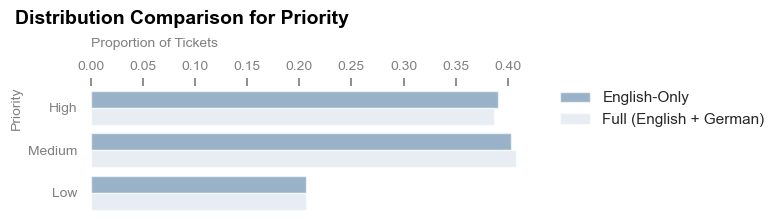


Proportions table for Type:


,Type,Dataset,Proportion
0,Change,English-Only,0.100392
1,Incident,English-Only,0.402134
2,Request,English-Only,0.286101
3,Problem,English-Only,0.211373
4,Change,Full (English + German),0.101755
5,Incident,Full (English + German),0.402870
6,Request,Full (English + German),0.286183
7,Problem,Full (English + German),0.209192


Visual for Type:


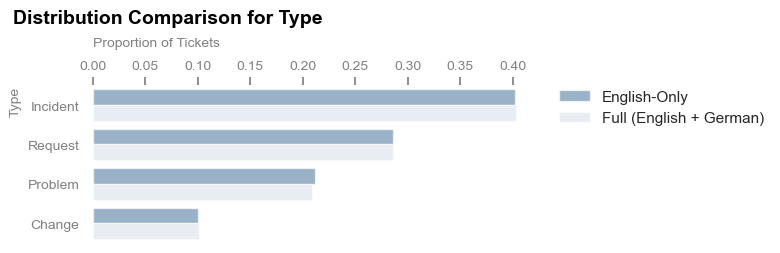


Proportions table for Queue:


,Queue,Dataset,Proportion
0,Product Support,English-Only,0.184295
1,Human Resources,English-Only,0.019117
2,Service Outages and Maintenance,English-Only,0.041385
3,Returns and Exchanges,English-Only,0.049549
4,Billing and Payments,English-Only,0.098008
5,General Inquiry,English-Only,0.013620
6,Sales and Pre-Sales,English-Only,0.030837
7,IT Support,English-Only,0.118943
8,Customer Service,English-Only,0.150831
9,Technical Support,English-Only,0.293416


Visual for Queue:


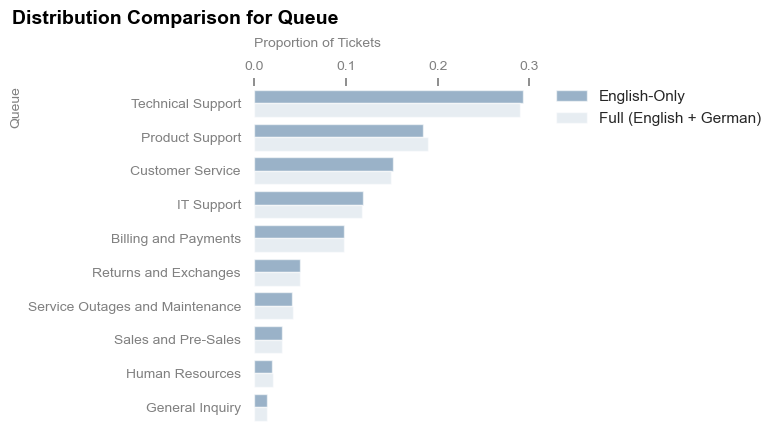


Proportions table for Version:


,Version,Dataset,Proportion
0,52,English-Only,0.307602
1,51,English-Only,0.035121
2,400,English-Only,0.657277
3,52,Full (English + German),0.314444
4,51,Full (English + German),0.040134
5,400,Full (English + German),0.645422


Visual for Version:


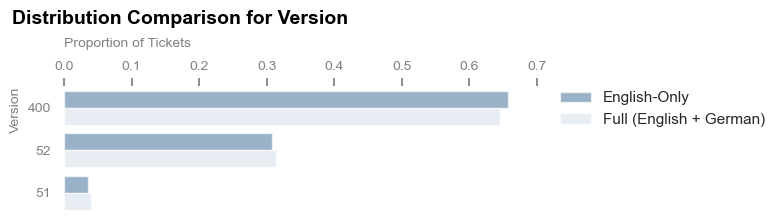

In [22]:
# Apply Seaborn theme globally
sns.set_theme(style="white")

# Exporting visual parameters for all dimensions
visual_params_df = pd.DataFrame([])

# Loop through columns to plot each distribution comparison
for col, tbl in distributions.items():
    # Prepare tidy data for Seaborn (long-form melt)
    df_plot = tbl.melt(
        id_vars=[col],
        value_vars=["full_pct", "en_pct"],
        var_name="Dataset",
        value_name="Proportion",
    )

    # Replace dataset labels for better readability of the legend
    df_plot["Dataset"] = df_plot["Dataset"].replace(
        {"full_pct": "Full (English + German)", "en_pct": "English-Only"}
    )

    # Place English dataset first for consistent coloring
    df_plot["Dataset"] = df_plot["Dataset"].sort_values(
        ascending=True, ignore_index=True
    )

    df_plot_temp = df_plot.copy()
    df_plot_temp["Dimension"] = col
    df_plot_temp = df_plot_temp.rename(columns={col: "Category"})
    visual_params_df = pd.concat([visual_params_df, df_plot_temp], ignore_index=True)

    # Ensure Version is treated as categorical string for proper plotting
    if col == "Version":
        df_plot[col] = df_plot[col].astype(str)

    print(f"\nProportions table for {col}:")
    display(df_plot)

    # Order columns for plotting
    if col == "Priority":
        order = ["High", "Medium", "Low"]
    elif col == "Version":
        order = ["400", "52", "51"]
    else:
        # Default sort is with largest proportions at the top for better readability
        order = (
            df_plot.groupby(col, observed=True)["Proportion"]
            .mean()
            .sort_values(ascending=False)
            .index.tolist()
        )

    ordered_df = pd.Categorical(df_plot[col], categories=order, ordered=True)

    # Setting the size of the plot based on the number of categories
    num_cats = df_plot[col].nunique()
    fig_height = 1.5 + num_cats * 0.3
    fig_width = max(8, 1.5 + num_cats * 0.6)

    # Initialize the matplotlib figure
    f, ax = plt.subplots(figsize=(fig_width, fig_height))

    # Create horizontal bar plot
    sns.barplot(
        data=df_plot,
        x="Proportion",
        y=col,
        hue="Dataset",
        saturation=0.7,
        palette=["steelblue", "#D3E1EE"],
        order=ordered_df.categories,
        alpha=0.6,
    )

    # Set x-axis ticks based on maximum proportion for better readability
    if max(df_plot["Proportion"]) > 0.6:
        ax.xaxis.set_ticks(np.arange(0, 0.71, 0.1))

    # Clean borders by removing bottom/right spines
    sns.despine(left=True, top=True, bottom=True, right=True)

    # Set labels and markers to grey for subtlety
    ax.set_xlabel("Proportion of Tickets", color="grey")
    ax.set_ylabel(col, color="grey")
    ax.tick_params(colors="grey")

    # Default x position for title
    if col == "Priority":
        x = -0.17
        loc = "left"
        leg_y = 1.07
    elif col == "Type":
        x = -0.18
        loc = "left"
        leg_y = 1.06
    elif col == "Queue":
        x = 0.3
        loc = "right"
        leg_y = 1.03
    else:
        x = -0.11
        loc = "left"
        leg_y = 1.07

    # Set font size to 10 for better readability and align labels to the left
    ax.yaxis.label.set_size(10)
    ax.xaxis.label.set_size(10)
    ax.tick_params(labelsize=10)

    # X-axis on top for better readability
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    ax.xaxis.label.set_horizontalalignment("left")
    ax.xaxis.label.set_position((0, leg_y))
    ax.xaxis.labelpad = 10  # Add padding to the x-axis label for better spacing

    # Y-axis label alignment and position for better aesthetics
    ax.yaxis.label.set_horizontalalignment("right")
    ax.yaxis.label.set_position((0, 1))

    # Set title with font size 14 and grey color for subtlety
    ax.set_title(
        f"Distribution Comparison for {col}",
        fontsize=14,
        fontweight="bold",
        color="black",
        pad=10,
        loc=loc,
        x=x,
    )

    # Move legend to the right side of the plot
    ax.legend(bbox_to_anchor=(1.02, leg_y), loc="upper left", edgecolor="white")

    # Key of column for filename
    position = list(comparrison_cols.keys())[list(comparrison_cols.values()).index(col)]

    # Adjust layout and save figure
    plt.tight_layout()
    image_path = Config.REP_IMG_DIR / f"{position}_Distribution_Comparison_{col}.png"
    plt.savefig(image_path, dpi=300, bbox_inches="tight")

    # Re-order columns and save visual parameters
    visual_params_df = visual_params_df[
        ["Dimension", "Dataset", "Category", "Proportion"]
    ]
    visual_params_df.to_csv(Config.VISUAL_PARAMS_PATH, index=False, encoding="utf-8")

    print(f"Visual for {col}:")
    plt.show()

### Chi-square and Cramer's V Tests

Interpretation guidance for Cramer's V (rule-of-thumb): 0.00-0.10: negligible, 0.10-0.20: weak, 0.20-0.40: moderate, >0.40: strong association

In [ ]:
# Define parameters for Cramer's test: chi2: chi-square result, n: sample size, r: number of rows, k: number of coumns
def cramers_v(chi2, n, r, k):
    return np.sqrt(chi2 / (n * min(r - 1, k - 1)))


# Initialise outputs array for stats results
tests = []

for col, tbl in distributions.items():
    # contingency table: rows=categories, cols = counts [full, en]
    ct = tbl[["full_count", "en_count"]].values
    chi2, p, dof, expected = stats.chi2_contingency(ct, correction=False)
    n = ct.sum()
    r, k = ct.shape
    v = cramers_v(chi2, n, r, k)

    tests.append(
        {
            "Dimension": col,
            "Chi2": chi2,
            "p_value": p,
            "DoF": dof,
            "n": n,
            "Cramers_V": v,
        }
    )

# Produce a dataframe using the stats result's array and save it
stats_df = pd.DataFrame(tests)

stats_df.to_csv(
    Config.STATISTICAL_SUMMARY_PATH, index=False, encoding="utf-8", float_format="%.3e"
)

print("\nChi-square and Cramér's V test results for distribution differences:")
display(
    stats_df.style.format(
        {"Chi2": "{:.3f}", "p_value": "{:.2e}", "n": "{:,}", "Cramers_V": "{:.2e}"}
    )
)


Chi-square and Cramér's V test results for distribution differences:


,Dimension,Chi2,p_value,DoF,n,Cramers_V
0,Priority,0.728,6.95e-01,2,"38,472",4.35e-03
1,Type,0.374,9.46e-01,3,"38,472",3.12e-03
2,Queue,4.112,9.04e-01,9,"38,472",1.03e-02
3,Version,9.245,9.83e-03,2,"38,472",1.55e-02


All observed differences fell well below thresholds of practical concern (Cramér’s V < 0.1, total L1 < 1 %), confirming that subsequent analyses using English-only data was robust against language-sampling bias. Therefore, the English subset was saved as a Parquet file for downstream use.